# Dataset Loader - tf.data Pipeline

Builds the model input pipeline from the preprocessing manifest:

1. **Load** each preprocessed `(224, 224)` grayscale slice from `manifest.csv`
2. **Expand to 3 channels** via `to_three_channels` so the pretrained backbones
   (ResNet50, EfficientNetV2, DenseNet121) accept it
3. **Augment** (train split only) using the transforms in `configs/config.yaml`
4. **Batch + prefetch** for training

**Prerequisite:** `data/processed/manifest.csv` exists (run `python src/preprocess.py`).

In [1]:
import sys
import os
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import yaml
import matplotlib.pyplot as plt
import tensorflow as tf
import keras


def _find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for _ in range(10):
        if (current / "configs" / "config.yaml").exists():
            return current
        current = current.parent
    raise SystemExit(
        "Could not locate configs/config.yaml. Run the notebook from "
        "anywhere inside the repository."
    )


REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

with open(REPO_ROOT / "configs" / "config.yaml", "r") as fh:
    config = yaml.safe_load(fh)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.titlesize": 11,
    "axes.labelsize": 9,
})

print("TensorFlow:", tf.__version__)
print("Keras     :", keras.__version__)
print("Config loaded.")

# absolute paths so everything works regardless of the kernel's CWD
config["data"]["processed_dir"] = str(REPO_ROOT / config["data"]["processed_dir"])

TensorFlow: 2.21.0
Keras     : 3.15.1
Config loaded.


In [2]:
from src.preprocessing.slices import to_three_channels
from src.preprocessing.augmentation import build_augmentation_layer
from src.data.loader import (
    load_manifest,
    create_train_val_datasets,
    count_per_split,
)

manifest = load_manifest(REPO_ROOT / config["data"]["processed_dir"])
print("Total slices in manifest:", len(manifest))
print("Slices per split        :", count_per_split(manifest))
print()
print(manifest.groupby(["split", "sequence"]).size().to_string())
print()
print("Class distribution per split:")
print(manifest.groupby(["split", "label"]).size().to_string())
print("\n(label 1 = endometriosis / UT-EndoMRI; label 0 = healthy, pending dataset)")

Total slices in manifest: 22178
Slices per split        : {'train': 17201, 'validation': 4977}

split       sequence
train       T1          4640
            T1FS        7446
            T2          3206
            T2FS        1909
validation  T1          1434
            T1FS        1882
            T2          1036
            T2FS         625

Class distribution per split:
split       label
train       1        17201
validation  1         4977

(label 1 = endometriosis / UT-EndoMRI; label 0 = healthy, pending dataset)


In [3]:
train_ds, val_ds = create_train_val_datasets(config)

val_batches = sum(1 for _ in val_ds)
print(f"Validation dataset: {val_batches} batches")
print("Dataset objects ready - train augmented + shuffled, validation deterministic.")

Validation dataset: 156 batches
Dataset objects ready - train augmented + shuffled, validation deterministic.


In [4]:
xb, yb = next(iter(train_ds.take(1)))
xv, yv = next(iter(val_ds.take(1)))

print("TRAIN batch")
print("  images :", xb.shape, xb.dtype)
print("  labels :", yb.shape, yb.dtype, "min", yb.numpy().min(), "max", yb.numpy().max())
print("  range  : %.4f .. %.4f" % (xb.numpy().min(), xb.numpy().max()))
ch0, ch1, ch2 = xb.numpy()[0, :, :, 0], xb.numpy()[0, :, :, 1], xb.numpy()[0, :, :, 2]
print("  channel 0 == 1 == 2 :", bool((ch0 == ch1).all() and (ch1 == ch2).all()))

print("VALIDATION batch")
print("  images :", xv.shape, xv.dtype)
print("  labels :", yv.shape, yv.dtype)
print("  range  : %.4f .. %.4f" % (xv.numpy().min(), xv.numpy().max()))

assert xb.shape[1:] == (224, 224, 3)
assert xv.shape[1:] == (224, 224, 3)
assert xb.dtype == tf.float32
assert yb.dtype == tf.int32
print("\nAssertions passed: yields ((B, 224, 224, 3) float32, (B,) int32).")

TRAIN batch
  images : (32, 224, 224, 3) <dtype: 'float32'>
  labels : (32,) <dtype: 'int32'> min 1 max 1
  range  : 0.0000 .. 0.9791
  channel 0 == 1 == 2 : True
VALIDATION batch
  images : (32, 224, 224, 3) <dtype: 'float32'>
  labels : (32,) <dtype: 'int32'>
  range  : 0.0000 .. 1.0000

Assertions passed: yields ((B, 224, 224, 3) float32, (B,) int32).


## Augmentation in action

The transforms come from `configs/config.yaml` and are applied **per batch,
per epoch, train split only**. Config mapping to Keras 3 layers:

| Config | Keras layer | Note |
|---|---|---|
| `rotation_range: 15` | `RandomRotation(factor=15/360)` | Keras 3 factor is a fraction of 2π |
| `zoom_range: [0.8, 1.2]` | `RandomZoom(factor∈[−0.2, 0.2])` | Keras 3 factor is an offset from 1 |
| `translation_shift: 0.1` | `RandomTranslation(factor=0.1)` | fraction of spatial dims |

Below: one real slice, then 7 random augmentations produced by the same layer.

Augmentation pipeline: ['RandomRotation', 'RandomZoom', 'RandomTranslation']


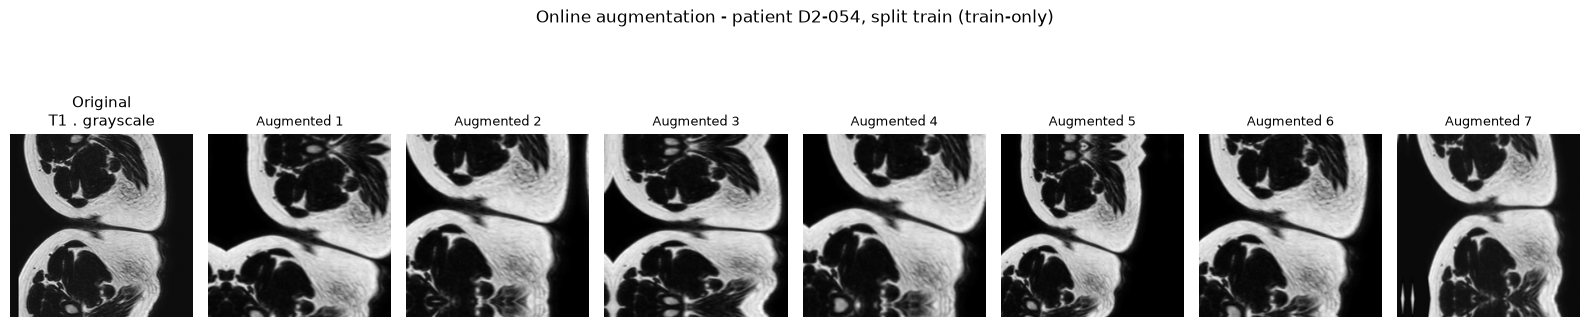

Base slice : (224, 224, 3) float32
Intensity range preserved : 0.0000 .. 1.0000


In [5]:
aug_layer = build_augmentation_layer(config)
print(
    "Augmentation pipeline:",
    "None (disabled in config)"
    if aug_layer is None
    else [layer._name if getattr(layer, "_name", None) else type(layer).__name__ for layer in aug_layer.layers],
)

row = manifest.iloc[0]
slice_path = REPO_ROOT / config["data"]["processed_dir"] / row["filename"]
base = to_three_channels(np.load(slice_path))

fig, axes = plt.subplots(1, 8, figsize=(16, 4))
axes[0].imshow(base[:, :, 0], cmap="gray")
axes[0].set_title(f"Original\n{row['sequence']} . grayscale")
axes[0].axis("off")

for i in range(1, 8):
    tf.random.set_seed(1000 + i)
    aug = aug_layer(base[None, ...], training=True)
    axes[i].imshow(aug[0, :, :, 0].numpy(), cmap="gray")
    axes[i].set_title(f"Augmented {i}", fontsize=9)
    axes[i].axis("off")

plt.suptitle(
    f"Online augmentation - patient {row['patient_id']}, split {row['split']} (train-only)",
    y=1.0,
)
plt.tight_layout()
plt.show()

print(f"Base slice : {base.shape} {base.dtype}")
print(f"Intensity range preserved : {base.min():.4f} .. {base.max():.4f}")

## Where this lands

This pipeline is the exact input contract for the model phase: `(224, 224, 3)`
float32 tensors in `[0, 1]`, batched for `model.fit()`. Augmentation is **online**
(random in every epoch), not baked into `data/processed/`, so it scales without
extra storage and improves generalization.

**Next step (blocked externally):** training awaits the healthy pelvis + test
datasets so both classes - and honest evaluation - exist. In the meantime the
pipeline is fully exercised on all positive (label-1) slices above.